In [1]:
%matplotlib widget
import ipympl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from scipy.interpolate import interp1d
import os
import glob

from core import *



c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [4]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
DATA_DIR = r"Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107"
FIG_DIR = os.path.join(DATA_DIR, "figures")
ANALYSIS_DIR = os.path.join(DATA_DIR, "gplvm_results")
SESSION_NAME = os.path.basename(DATA_DIR)
BASE_NAME = SESSION_NAME
PROBES = [0, 1, 2, 3]  # List of probe numbers to include


# Spike rate computation parameters
WINDOW_SIZE = 0.01         # s
STEP_SIZE   = 0.01       # s
USE_UNITS   = "good"       # {'all', 'good', 'mua'}


# Filtering thresholds
MIN_TOTAL_SPIKES   = 500
MIN_MEAN_RATE_HZ   = 0.01
MIN_PRESENCE_RATIO = 0.50
N_TIME_BINS        = 100    # coarse bins for presence ratio


# defining the region dictionary. Keys are probe numbers, values are dictionaries which are further mapping shanks to regions
region_dict = {
    0: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'},
    1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'},
    2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'Th', 5: 'Th'}, 
    3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'}
} #This is going to need to be replaced by manual unit labels....


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
hemisphere_dict = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}

# Create figure directory if it doesn't exist
os.makedirs(FIG_DIR, exist_ok=True)

In [5]:
def load_spike_times(ks_dir, use_units='good'):
    """Load spike times from Kilosort output directory."""
    # Load cluster info
    cluster_info_path = os.path.join(ks_dir, 'cluster_group.tsv')
    cluster_info = np.genfromtxt(cluster_info_path, delimiter='\t', names=True, dtype=None, encoding='utf-8')
    
    # Determine which clusters to use
    if use_units == 'good':
        valid_clusters = cluster_info['cluster_id'][cluster_info['KSLabel'] == 'good']
    elif use_units == 'mua':
        valid_clusters = cluster_info['cluster_id'][(cluster_info['KSLabel'] == 'mua') | (cluster_info['KSLabel'] == 'good')]
    else:
        valid_clusters = cluster_info['cluster_id']
    
    # Load spike times
    spike_times_path = os.path.join(ks_dir, 'spike_times_sec_adj.npy')
    all_spike_times = np.load(spike_times_path)  # in seconds
    
    # Load spike clusters
    spike_clusters_path = os.path.join(ks_dir, 'spike_clusters.npy')
    all_spike_clusters = np.load(spike_clusters_path)
    
    # Filter spikes for valid clusters
    spike_times = {}
    for cluster_id in valid_clusters:
        spike_times[cluster_id] = all_spike_times[all_spike_clusters == cluster_id]
    
    return spike_times

In [6]:
spike_times = {}
for probe in PROBES:

        
    # Get the raw spike counts and the zscored and smoothed spike rates
    pattern = os.path.join(DATA_DIR, f"Kilosort*imec{probe}*")
    matches = glob.glob(pattern)
    ks_dir = matches[0]  # assuming there's only one match
    print(f"Loading spike times from Kilosort directory: {ks_dir}")

    spike_times[probe] = load_spike_times(ks_dir, use_units=USE_UNITS)
    print(spike_times[probe].keys())
    

Loading spike times from Kilosort directory: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107\Kilosort_imec0_ks4
dict_keys([2, 7, 11, 14, 16, 21, 24, 25, 30, 31, 33, 34, 35, 36, 44, 46, 47, 48, 50, 52, 54, 57, 58, 59, 60, 62, 63, 64, 66, 67, 71, 72, 73, 77, 80, 82, 86, 87, 89, 90, 92, 93, 98, 99, 101, 103, 104, 106, 107, 110, 111, 113, 114, 116, 155, 165, 168, 172, 174, 176, 186, 187, 189, 192, 198, 201, 208, 209, 215, 220, 221, 223, 225, 226, 228, 229, 233, 236, 237, 241, 247, 248, 249, 253, 254, 257, 262, 266, 267, 269, 272, 273, 274, 276, 281, 282, 283, 284, 288, 292, 294, 298, 300, 303, 304, 316, 324, 339, 344, 356, 361, 362, 363, 373, 379, 382])
Loading spike times from Kilosort directory: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107\Kilosort_imec1_ks4
dict_keys([0, 8, 17, 82, 86, 88, 89, 92, 105, 106, 118, 120, 123, 125, 126, 131, 134, 141, 146, 151, 156, 158, 159, 162, 163, 172, 174, 176, 182, 183, 189, 191, 197, 200, 204, 206, 208, 211, 212, 213, 219, 222, 2

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def plot_bilateral_spike_rasters(
    spike_times_by_probe: dict,
    hemisphere_dict: dict,
    start_s: float,
    end_s: float,
    bin_s: float = 0.01,
    step_s: float = 0.01,
    figsize=(14, 10),
    linewidth: float = 0.8,
    alpha: float = 0.95,
    sort_method: str = "hierarchical",  # {"hierarchical", "pca"}
    title: str | None = None,
    drop_silent_in_window: bool = True,
    min_spikes_in_window: int = 1,

):
    """
    Make a 2-panel spike raster plot (Left vs Right hemisphere). Units are color-coded
    (each unit gets its own color) and *sorted within hemisphere* by similarity of
    binned activity (correlation-based ordering).

    Parameters
    ----------
    spike_times_by_probe : dict
        {probe_id: {cluster_id: 1D array of spike times in seconds}}
        (This matches how you're building `spike_times[probe] = load_spike_times(...)`.)
    hemisphere_dict : dict
        {probe_id: 'L' or 'R'} mapping probes to hemispheres.
    start_s, end_s : float
        Time window to display (seconds).
    bin_s, step_s : float
        Bin width and step for constructing binned activity vectors used for correlation sorting.
        (This does NOT affect the raster itself; it only affects sorting.)
    sort_method : str
        "hierarchical": correlation distance + hierarchical clustering leaves order
        "pca": order by projection onto first PC of z-scored binned activity
    Returns
    -------
    fig, axes, meta : (matplotlib Figure, ndarray[Axes], dict)
        meta contains the unit ordering and unit identifiers used.
    """
    assert end_s > start_s, "end_s must be > start_s"
    assert bin_s > 0 and step_s > 0, "bin_s and step_s must be > 0"

    # ------------------------ Helpers ------------------------

    def _iter_units_for_hemi(hemi: str):
        """Yield (unit_key, spike_times_array) for a hemisphere, where unit_key is (probe, cluster)."""
        for probe, clusters in spike_times_by_probe.items():
            if hemisphere_dict.get(probe, None) != hemi:
                continue
            for cid, st in clusters.items():
                if st is None:
                    continue
                yield (probe, int(cid)), np.asarray(st, dtype=float)

    def _build_binned_matrix(units, t0, t1, bin_s, step_s):
        """
        Build binned count (or rate) matrix for correlation sorting.
        Shape: (n_units, n_bins)
        """
        # Define bin starts for sliding windows
        # windows: [t, t+bin_s)
        starts = np.arange(t0, t1 - bin_s + 1e-12, step_s)
        n_bins = len(starts)
        n_units = len(units)
        X = np.zeros((n_units, n_bins), dtype=float)

        # Precompute window edges as (start, end)
        ends = starts + bin_s

        for i, (_, st) in enumerate(units):
            # restrict spikes to [t0, t1)
            s = st[(st >= t0) & (st < t1)]
            if s.size == 0:
                continue

            # Efficient-ish counting in sliding windows:
            # For each window, count spikes with binary search
            # count = idx_right(end) - idx_left(start)
            s_sorted = np.sort(s)
            left_idx = np.searchsorted(s_sorted, starts, side="left")
            right_idx = np.searchsorted(s_sorted, ends, side="left")
            counts = (right_idx - left_idx).astype(float)

            # Convert to rate (Hz) for better comparability across bin sizes
            X[i, :] = counts / bin_s

        return X

    def _corr_order(X, method="hierarchical"):
        """Return an ordering of rows in X based on correlation similarity."""
        n = X.shape[0]
        if n <= 1:
            return np.arange(n, dtype=int)

        # Z-score each unit's activity vector (avoid zero-std issues)
        Xz = X - X.mean(axis=1, keepdims=True)
        sd = Xz.std(axis=1, keepdims=True)
        sd[sd < 1e-12] = 1.0
        Xz /= sd

        if method == "pca":
            # First principal component ordering via SVD
            # score = U[:,0] * S[0] (equivalently projection)
            U, S, Vt = np.linalg.svd(Xz, full_matrices=False)
            scores = U[:, 0] * S[0]
            return np.argsort(scores)

        # Default: hierarchical clustering on correlation distance
        # distance = 1 - corr
        C = np.corrcoef(Xz)
        C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
        D = 1.0 - C

        # Condensed distance vector for linkage
        # scipy is optional; if unavailable, fall back to PCA ordering
        try:
            from scipy.spatial.distance import squareform
            from scipy.cluster.hierarchy import linkage, leaves_list

            dcond = squareform(D, checks=False)
            Z = linkage(dcond, method="average")
            order = leaves_list(Z)
            return order
        except Exception:
            # Fallback if scipy isn't available
            U, S, Vt = np.linalg.svd(Xz, full_matrices=False)
            scores = U[:, 0] * S[0]
            return np.argsort(scores)

    def _raster_panel(ax, units_sorted, t0, t1, panel_label, lineoffset=1.0, linelength=0.9):
        """
        Clean raster using eventplot so each unit occupies a fixed row
        regardless of how many spikes it has in the time window.
        """
        n_units = len(units_sorted)

        if n_units == 0:
            ax.text(0.5, 0.5, f"No units in {panel_label}",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_xlim(t0, t1)
            ax.set_ylim(0, 1)
            ax.set_yticks([])
            return

        # Collect spike times per unit
        events = []
        for (_, _), st in units_sorted:
            s = st[(st >= t0) & (st <= t1)]
            events.append(s)

        # One distinct color per unit
        cmap = plt.get_cmap("hsv")
        colors = [cmap(i / max(n_units, 2)) for i in range(n_units)]

        # Y positions: one row per unit
        offsets = np.arange(n_units) * lineoffset

        ax.eventplot(
            events,
            orientation="horizontal",
            lineoffsets=offsets,
            linelengths=linelength,
            colors=colors,
            linewidths=0.8,
            alpha=0.95,
        )

        ax.set_xlim(t0, t1)
        ax.set_ylim(-lineoffset, offsets[-1] + lineoffset)
        ax.set_ylabel(f"{panel_label} units (sorted)")
        # setting y tick for the max unit only
        ax.set_yticks([offsets[-1]])
        ax.set_yticklabels([f"{n_units}"])

    # ------------------------ Assemble data ------------------------

    left_units = list(_iter_units_for_hemi("L"))
    right_units = list(_iter_units_for_hemi("R"))

    # Binned matrices for sorting (using the *same* time window you want to view)
    XL = _build_binned_matrix(left_units, start_s, end_s, bin_s, step_s) if len(left_units) else np.zeros((0, 0))
    XR = _build_binned_matrix(right_units, start_s, end_s, bin_s, step_s) if len(right_units) else np.zeros((0, 0))

    orderL = _corr_order(XL, method=sort_method) if len(left_units) else np.array([], dtype=int)
    orderR = _corr_order(XR, method=sort_method) if len(right_units) else np.array([], dtype=int)

    left_sorted = [left_units[i] for i in orderL] if len(left_units) else []
    right_sorted = [right_units[i] for i in orderR] if len(right_units) else []

    def _filter_for_display(units_sorted, t0, t1, min_spikes):
        kept = []
        dropped = 0
        for unit_key, st in units_sorted:
            n = np.sum((st >= t0) & (st <= t1))
            if n >= min_spikes:
                kept.append((unit_key, st))
            else:
                dropped += 1
        return kept, dropped

    if drop_silent_in_window:
        left_sorted, droppedL = _filter_for_display(left_sorted, start_s, end_s, min_spikes_in_window)
        right_sorted, droppedR = _filter_for_display(right_sorted, start_s, end_s, min_spikes_in_window)
    else:
        droppedL = droppedR = 0


    # ------------------------ Plot ------------------------

    fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, constrained_layout=True)

    _raster_panel(axes[0], right_sorted, start_s, end_s, panel_label="right hemisphere")
    _raster_panel(axes[1], left_sorted, start_s, end_s, panel_label="left hemisphere")

    axes[1].set_xlabel("Time (s)")
    if title is None:
        title = f"Spike rasters (sorted by correlation; bin={bin_s:.3g}s, step={step_s:.3g}s)"
    fig.suptitle(title, y=1.02)

    meta = {
        "left_order": [k for (k, _) in left_sorted],   # list of (probe, cluster)
        "right_order": [k for (k, _) in right_sorted],
        "sort_method": sort_method,
        "bin_s": bin_s,
        "step_s": step_s,
        "start_s": start_s,
        "end_s": end_s,
    }
    return fig, axes, meta



c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\SB13FLPC020\miniforge3\envs\pmgplvm\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


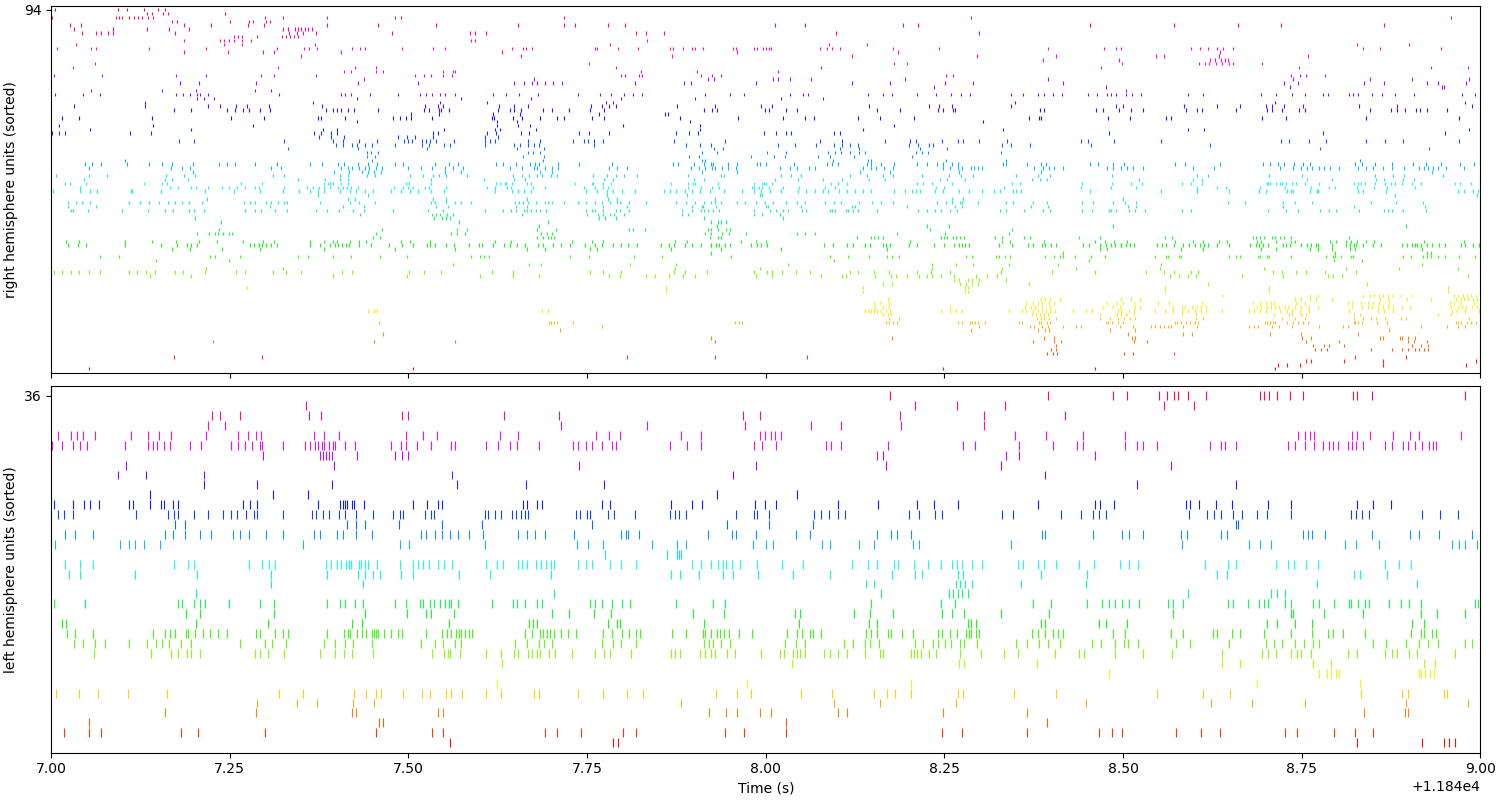

In [20]:



fig, axes, meta = plot_bilateral_spike_rasters(
     spike_times_by_probe=spike_times,          # your dict {probe: {cluster: times}}
     hemisphere_dict=hemisphere_dict,           # {probe: 'L'/'R'}
     start_s=11847,
     end_s=11849,
     bin_s=WINDOW_SIZE,
     step_s=STEP_SIZE,
     sort_method="hierarchical",
     figsize=(15, 8),
     min_spikes_in_window=5,
     alpha=1
)

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def compute_ccg(spk_ref, spk_tgt, bin_s=0.001, half_window_s=0.05, t0=None, t1=None):
    """
    Compute cross-correlogram counts for tgt relative to ref:
        tau = t_tgt - t_ref
    using a +/- half_window_s window and bin_s bin width.

    Returns
    -------
    centers : (n_bins,) bin centers (seconds)
    counts  : (n_bins,) histogram counts
    """
    spk_ref = np.asarray(spk_ref, dtype=float)
    spk_tgt = np.asarray(spk_tgt, dtype=float)

    if t0 is not None:
        spk_ref = spk_ref[spk_ref >= t0]
        spk_tgt = spk_tgt[spk_tgt >= t0]
    if t1 is not None:
        spk_ref = spk_ref[spk_ref <= t1]
        spk_tgt = spk_tgt[spk_tgt <= t1]

    if spk_ref.size == 0 or spk_tgt.size == 0:
        edges = np.arange(-half_window_s, half_window_s + bin_s, bin_s)
        centers = 0.5 * (edges[:-1] + edges[1:])
        return centers, np.zeros_like(centers)

    spk_tgt = np.sort(spk_tgt)

    edges = np.arange(-half_window_s, half_window_s + bin_s, bin_s)
    counts = np.zeros(len(edges) - 1, dtype=int)

    # For each ref spike, look up target spikes within [ref-half_window, ref+half_window]
    for tr in spk_ref:
        left = np.searchsorted(spk_tgt, tr - half_window_s, side="left")
        right = np.searchsorted(spk_tgt, tr + half_window_s, side="right")
        if right <= left:
            continue
        d = spk_tgt[left:right] - tr
        # histogram diffs into edges
        counts += np.histogram(d, bins=edges)[0]

    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts


def save_all_cross_correlograms(
    spike_times_by_probe: dict,
    hemisphere_dict: dict,
    out_dir: str,
    start_s: float | None = None,
    end_s: float | None = None,
    bin_s: float = 0.001,
    half_window_s: float = 0.05,
    min_spikes: int = 50,
    pairs: str = "all",              # {"all", "within_hemi", "across_hemi"}
    overwrite: bool = False,
    max_pairs: int | None = None,    # safety valve if you accidentally have huge unit counts
):
    """
    Compute cross-correlograms for (optionally) all unit pairs and save per-pair figures
    into an organized directory structure.

    Directory structure (under out_dir):
      out_dir/
        L/
          (probe,cluster)_REF/
            REF__TGT_<hemi>/REF__TGT__ccg.png
        R/
          ...
        LR/
          (probe,cluster)_REF/
            ...

    Notes
    -----
    - We define CCG as: tau = t_tgt - t_ref.
    - We filter units by total spikes in [start_s, end_s] (if provided) >= min_spikes.
    - If you truly mean "all probes + all hemispheres", choose pairs="all".
    - For large datasets, per-pair PNGs can explode in count; use max_pairs to cap.
    """
    os.makedirs(out_dir, exist_ok=True)

    # -------- collect units with hemisphere labels --------
    units = []  # list of dicts: {"key": (probe, cluster), "hemi": 'L'/'R', "spk": array}
    for probe, clusters in spike_times_by_probe.items():
        hemi = hemisphere_dict.get(probe, None)
        if hemi not in ("L", "R"):
            continue
        for cid, st in clusters.items():
            st = np.asarray(st, dtype=float)
            if start_s is not None:
                st = st[st >= start_s]
            if end_s is not None:
                st = st[st <= end_s]
            if st.size >= min_spikes:
                units.append({"key": (int(probe), int(cid)), "hemi": hemi, "spk": np.sort(st)})

    if len(units) == 0:
        raise ValueError("No units passed filters (min_spikes / time window).")

    # Split by hemisphere
    units_L = [u for u in units if u["hemi"] == "L"]
    units_R = [u for u in units if u["hemi"] == "R"]

    def _pair_iter():
        # yields (ref_unit, tgt_unit, hemi_pair_label)
        if pairs == "within_hemi":
            for group, label in ((units_L, "L"), (units_R, "R")):
                for i in range(len(group)):
                    for j in range(len(group)):
                        if i == j:
                            continue
                        yield group[i], group[j], label
        elif pairs == "across_hemi":
            for ref in units_L:
                for tgt in units_R:
                    yield ref, tgt, "LR"
            for ref in units_R:
                for tgt in units_L:
                    yield ref, tgt, "RL"
        else:  # "all"
            for i in range(len(units)):
                for j in range(len(units)):
                    if i == j:
                        continue
                    hemi_pair = units[i]["hemi"] + units[j]["hemi"]
                    yield units[i], units[j], hemi_pair

    # -------- iterate and save --------
    n_done = 0
    index_rows = []

    for ref, tgt, hemi_pair in _pair_iter():
        if max_pairs is not None and n_done >= max_pairs:
            break

        ref_key = ref["key"]  # (probe, cluster)
        tgt_key = tgt["key"]

        # Build directories:
        # out_dir/<hemi_pair>/<ref_probe>_<ref_cluster>/
        ref_name = f"p{ref_key[0]:02d}_c{ref_key[1]:04d}"
        tgt_name = f"p{tgt_key[0]:02d}_c{tgt_key[1]:04d}"
        pair_dir = os.path.join(out_dir, hemi_pair, ref_name)
        os.makedirs(pair_dir, exist_ok=True)

        fname = f"{ref_name}__{tgt_name}__ccg_bin{bin_s:g}_win{half_window_s:g}.png"
        fpath = os.path.join(pair_dir, fname)

        if (not overwrite) and os.path.exists(fpath):
            continue

        centers, counts = compute_ccg(
            ref["spk"], tgt["spk"],
            bin_s=bin_s,
            half_window_s=half_window_s,
            t0=None, t1=None
        )

        # ---- plot ----
        fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
        ax.bar(centers, counts, width=bin_s, align="center")
        ax.axvline(0.0, linewidth=1.0)
        ax.set_xlabel(r"$\tau = t_{\mathrm{tgt}} - t_{\mathrm{ref}}$ (s)")
        ax.set_ylabel("Count")
        ax.set_title(f"CCG  {ref_name} ({ref['hemi']}) → {tgt_name} ({tgt['hemi']})")

        # helpful annotation
        ann = []
        if start_s is not None or end_s is not None:
            ann.append(f"window: [{start_s if start_s is not None else '-inf'}, {end_s if end_s is not None else 'inf'}] s")
        ann.append(f"bin={bin_s:g}s  halfwin={half_window_s:g}s")
        ax.text(0.99, 0.98, "\n".join(ann), ha="right", va="top", transform=ax.transAxes, fontsize=9)

        fig.savefig(fpath, dpi=200)
        plt.close(fig)

        index_rows.append({
            "hemi_pair": hemi_pair,
            "ref_probe": ref_key[0],
            "ref_cluster": ref_key[1],
            "tgt_probe": tgt_key[0],
            "tgt_cluster": tgt_key[1],
            "bin_s": bin_s,
            "half_window_s": half_window_s,
            "start_s": start_s,
            "end_s": end_s,
            "path": fpath,
        })

        n_done += 1

    # Write a lightweight index for traceability
    index_path = os.path.join(out_dir, "ccg_index.tsv")
    with open(index_path, "w", encoding="utf-8") as f:
        cols = list(index_rows[0].keys()) if index_rows else []
        f.write("\t".join(cols) + "\n")
        for row in index_rows:
            f.write("\t".join(str(row[c]) for c in cols) + "\n")

    return {"n_units": len(units), "n_figs_saved": n_done, "index_path": index_path, "out_dir": out_dir}




In [ ]:



CCG_DIR = os.path.join(FIG_DIR, "cross_correlograms")
info = save_all_cross_correlograms(
    spike_times_by_probe=spike_times,
    hemisphere_dict=hemisphere_dict,
    out_dir=CCG_DIR,
    start_s=100.0,
    end_s=140.0,
     bin_s=0.001,
     half_window_s=0.05,
     min_spikes=50,
     pairs="all",   # try "within_hemi" or "all"
     max_pairs=100,        # set e.g. 5000 if you’re nervous
)
print(info)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _gaussian_smooth_1d(x, sigma_bins: float):
    """Gaussian smooth in 'bins' units without requiring scipy."""
    if sigma_bins <= 0:
        return x.astype(float, copy=True)
    radius = int(np.ceil(4 * sigma_bins))
    if radius < 1:
        return x.astype(float, copy=True)
    k = np.arange(-radius, radius + 1)
    w = np.exp(-0.5 * (k / sigma_bins) ** 2)
    w /= w.sum()
    return np.convolve(x, w, mode="same")

def compute_ccg_counts(spk_ref, spk_tgt, bin_s=0.001, half_window_s=0.25, t0=None, t1=None):
    """
    CCG counts for tau = t_tgt - t_ref over [-half_window_s, +half_window_s].
    """
    spk_ref = np.asarray(spk_ref, dtype=float)
    spk_tgt = np.asarray(spk_tgt, dtype=float)

    if t0 is not None:
        spk_ref = spk_ref[spk_ref >= t0]
        spk_tgt = spk_tgt[spk_tgt >= t0]
    if t1 is not None:
        spk_ref = spk_ref[spk_ref <= t1]
        spk_tgt = spk_tgt[spk_tgt <= t1]

    edges = np.arange(-half_window_s, half_window_s + bin_s, bin_s)
    centers = 0.5 * (edges[:-1] + edges[1:])
    counts = np.zeros(len(centers), dtype=int)

    if spk_ref.size == 0 or spk_tgt.size == 0:
        return centers, counts

    spk_tgt = np.sort(spk_tgt)

    for tr in spk_ref:
        left = np.searchsorted(spk_tgt, tr - half_window_s, side="left")
        right = np.searchsorted(spk_tgt, tr + half_window_s, side="right")
        if right <= left:
            continue
        d = spk_tgt[left:right] - tr
        counts += np.histogram(d, bins=edges)[0]

    return centers, counts

def theta_cycle_skipping_score(
    tau_s,
    ccg_counts,
    bin_s,
    expected_period_s=0.125,
    trough_window_s=0.010,      # window around 0 to assess the trough
    peak_window_s=0.015,        # window around +/-expected_period to assess peaks
    baseline_exclude_s=0.030,   # exclude central region from baseline estimate
    smooth_sigma_s=0.004,       # smoothing sigma in seconds (converted to bins)
    require_both_sides=True,    # require both +T and -T peaks
    min_trough_z=-1.0,          # trough at 0 must be <= baseline + z*sd (negative z)
    min_peak_z=+1.0,            # peak must be >= baseline + z*sd
    min_peak_over_trough=1.25,  # peak height must exceed trough by factor (in baseline-shifted units)
):
    """
    Returns:
      passes (bool), metrics (dict)
    """
    tau_s = np.asarray(tau_s, dtype=float)
    y = np.asarray(ccg_counts, dtype=float)

    # Smooth to stabilize peak/trough detection
    sigma_bins = smooth_sigma_s / bin_s
    ys = _gaussian_smooth_1d(y, sigma_bins=sigma_bins)

    # Masks
    def win(center, halfw):
        return (tau_s >= center - halfw) & (tau_s <= center + halfw)

    m0 = win(0.0, trough_window_s)
    mp = win(+expected_period_s, peak_window_s)
    mn = win(-expected_period_s, peak_window_s)

    # Baseline estimated from "side" lags excluding central region and excluding peak windows
    mb = (np.abs(tau_s) >= baseline_exclude_s) & (~mp) & (~mn)
    if mb.sum() < 10:
        # if window too small / masks too aggressive, relax baseline slightly
        mb = (np.abs(tau_s) >= baseline_exclude_s)

    base = np.median(ys[mb]) if mb.sum() else np.median(ys)
    mad = np.median(np.abs(ys[mb] - base)) if mb.sum() else np.median(np.abs(ys - base))
    sd = 1.4826 * mad
    if sd < 1e-9:
        sd = max(np.std(ys[mb]) if mb.sum() else np.std(ys), 1e-9)

    trough = np.min(ys[m0]) if m0.sum() else ys[np.argmin(np.abs(tau_s))]
    peak_p = np.max(ys[mp]) if mp.sum() else np.nan
    peak_n = np.max(ys[mn]) if mn.sum() else np.nan

    trough_z = (trough - base) / sd
    peakp_z = (peak_p - base) / sd if np.isfinite(peak_p) else -np.inf
    peakn_z = (peak_n - base) / sd if np.isfinite(peak_n) else -np.inf

    # Baseline-shifted (nonnegative-ish) quantities for ratio checks
    trough_bs = trough - base
    peakp_bs = peak_p - base if np.isfinite(peak_p) else -np.inf
    peakn_bs = peak_n - base if np.isfinite(peak_n) else -np.inf

    # Conditions
    cond_trough = trough_z <= min_trough_z
    cond_peakp = peakp_z >= min_peak_z
    cond_peakn = peakn_z >= min_peak_z
    if require_both_sides:
        cond_peaks = cond_peakp and cond_peakn
        peak_bs = min(peakp_bs, peakn_bs)
    else:
        cond_peaks = cond_peakp or cond_peakn
        peak_bs = max(peakp_bs, peakn_bs)

    # Peak-over-trough: want peak clearly above trough (which is below baseline)
    # We compare (peak-base) to (base-trough) magnitude.
    denom = max(base - trough, 1e-9)  # positive if trough below base
    ratio = peak_bs / denom

    cond_ratio = ratio >= min_peak_over_trough

    passes = bool(cond_trough and cond_peaks and cond_ratio)

    metrics = dict(
        base=base, sd=sd,
        trough=trough, peak_p=peak_p, peak_n=peak_n,
        trough_z=trough_z, peakp_z=peakp_z, peakn_z=peakn_z,
        peak_over_trough=ratio,
        expected_period_s=expected_period_s,
        smooth_sigma_s=smooth_sigma_s,
        trough_window_s=trough_window_s,
        peak_window_s=peak_window_s,
        require_both_sides=require_both_sides,
    )
    return passes, metrics, ys

def save_theta_cycle_skipping_ccgs(
    spike_times_by_probe: dict,
    hemisphere_dict: dict,
    out_dir: str,
    start_s: float | None = None,
    end_s: float | None = None,
    bin_s: float = 0.002,
    half_window_s: float = 0.30,
    min_spikes: int = 200,
    pairs: str = "across_hemi",        # {"within_hemi", "across_hemi", "all"}
    overwrite: bool = False,
    max_pairs: int | None = None,
    # theta-skipping criteria (forwarded to score fn)
    expected_period_s: float = 0.125,
    require_both_sides: bool = True,
    min_trough_z: float = -1.0,
    min_peak_z: float = +1.0,
    min_peak_over_trough: float = 1.25,
    smooth_sigma_s: float = 0.004,
    trough_window_s: float = 0.010,
    peak_window_s: float = 0.015,
    baseline_exclude_s: float = 0.030,
):
    """
    Compute CCGs for unit pairs, detect theta cycle-skipping signature, and ONLY save plots that pass.

    Organized directory structure:
      out_dir/
        L/ , R/ , LR/ , RL/ (depending on pairs)
          pXX_cYYYY/   (reference unit)
            pXX_cYYYY__pAA_cBBBB__thetaSkip_ccg.png
        theta_skip_index.tsv

    Returns a dict summary and writes an index TSV for all saved plots.
    """
    os.makedirs(out_dir, exist_ok=True)

    # ---- collect units passing a basic spike-count filter in [start_s, end_s] ----
    units = []  # each: {"key":(probe,cluster), "hemi":'L'/'R', "spk":sorted}
    for probe, clusters in spike_times_by_probe.items():
        hemi = hemisphere_dict.get(probe, None)
        if hemi not in ("L", "R"):
            continue
        for cid, st in clusters.items():
            st = np.asarray(st, dtype=float)
            if start_s is not None:
                st = st[st >= start_s]
            if end_s is not None:
                st = st[st <= end_s]
            if st.size >= min_spikes:
                units.append({"key": (int(probe), int(cid)), "hemi": hemi, "spk": np.sort(st)})

    if len(units) == 0:
        raise ValueError("No units passed filters. Lower min_spikes and/or widen the time window.")

    units_L = [u for u in units if u["hemi"] == "L"]
    units_R = [u for u in units if u["hemi"] == "R"]

    def _pair_iter():
        if pairs == "within_hemi":
            for group, label in ((units_L, "L"), (units_R, "R")):
                for i in range(len(group)):
                    for j in range(len(group)):
                        if i == j:
                            continue
                        yield group[i], group[j], label
        elif pairs == "across_hemi":
            for ref in units_L:
                for tgt in units_R:
                    yield ref, tgt, "LR"
            for ref in units_R:
                for tgt in units_L:
                    yield ref, tgt, "RL"
        else:  # "all"
            for i in range(len(units)):
                for j in range(len(units)):
                    if i == j:
                        continue
                    yield units[i], units[j], units[i]["hemi"] + units[j]["hemi"]

    saved = 0
    tested = 0
    index_rows = []

    for ref, tgt, hemi_pair in _pair_iter():
        if max_pairs is not None and tested >= max_pairs:
            break

        tested += 1
        ref_key, tgt_key = ref["key"], tgt["key"]
        ref_name = f"p{ref_key[0]:02d}_c{ref_key[1]:04d}"
        tgt_name = f"p{tgt_key[0]:02d}_c{tgt_key[1]:04d}"

        # Compute ccg
        tau, counts = compute_ccg_counts(
            ref["spk"], tgt["spk"],
            bin_s=bin_s,
            half_window_s=half_window_s,
            t0=None, t1=None
        )

        # Score theta skipping
        passes, metrics, smooth_counts = theta_cycle_skipping_score(
            tau, counts, bin_s=bin_s,
            expected_period_s=expected_period_s,
            trough_window_s=trough_window_s,
            peak_window_s=peak_window_s,
            baseline_exclude_s=baseline_exclude_s,
            smooth_sigma_s=smooth_sigma_s,
            require_both_sides=require_both_sides,
            min_trough_z=min_trough_z,
            min_peak_z=min_peak_z,
            min_peak_over_trough=min_peak_over_trough,
        )
        if not passes:
            continue

        # Save plot
        pair_dir = os.path.join(out_dir, hemi_pair, ref_name)
        os.makedirs(pair_dir, exist_ok=True)
        fname = (
            f"{ref_name}__{tgt_name}__thetaSkip"
            f"_T{expected_period_s*1000:.0f}ms"
            f"_bin{bin_s*1000:.1f}ms"
            f"_win{half_window_s*1000:.0f}ms.png"
        )
        fpath = os.path.join(pair_dir, fname)
        if (not overwrite) and os.path.exists(fpath):
            continue

        fig, ax = plt.subplots(figsize=(7.0, 3.8), constrained_layout=True)
        ax.bar(tau, counts, width=bin_s, align="center", alpha=0.35, label="raw")
        ax.plot(tau, smooth_counts, linewidth=1.5, label="smoothed")

        ax.axvline(0.0, linewidth=1.0)
        ax.axvline(+expected_period_s, linewidth=1.0, linestyle="--")
        ax.axvline(-expected_period_s, linewidth=1.0, linestyle="--")

        ax.set_xlabel(r"$\tau = t_{\mathrm{tgt}} - t_{\mathrm{ref}}$ (s)")
        ax.set_ylabel("Count")
        ax.set_title(f"Theta cycle skipping CCG  {ref_name} ({ref['hemi']}) → {tgt_name} ({tgt['hemi']})")

        info = [
            f"window: [{start_s if start_s is not None else '-inf'}, {end_s if end_s is not None else 'inf'}] s",
            f"bin={bin_s*1000:.1f} ms  halfwin={half_window_s*1000:.0f} ms  smoothσ={smooth_sigma_s*1000:.1f} ms",
            f"trough_z={metrics['trough_z']:.2f}  peak_z(+T)={metrics['peakp_z']:.2f}  peak_z(-T)={metrics['peakn_z']:.2f}",
            f"peak/|trough|={metrics['peak_over_trough']:.2f}",
        ]
        ax.text(0.99, 0.98, "\n".join(info), ha="right", va="top", transform=ax.transAxes, fontsize=9)

        ax.legend(loc="upper left", frameon=False)
        fig.savefig(fpath, dpi=200)
        plt.close(fig)

        saved += 1
        index_rows.append({
            "hemi_pair": hemi_pair,
            "ref_probe": ref_key[0],
            "ref_cluster": ref_key[1],
            "tgt_probe": tgt_key[0],
            "tgt_cluster": tgt_key[1],
            "bin_s": bin_s,
            "half_window_s": half_window_s,
            "expected_period_s": expected_period_s,
            "require_both_sides": require_both_sides,
            "trough_z": metrics["trough_z"],
            "peakp_z": metrics["peakp_z"],
            "peakn_z": metrics["peakn_z"],
            "peak_over_trough": metrics["peak_over_trough"],
            "start_s": start_s,
            "end_s": end_s,
            "path": fpath,
        })

    # Write index
    index_path = os.path.join(out_dir, "theta_skip_index.tsv")
    if index_rows:
        cols = list(index_rows[0].keys())
        with open(index_path, "w", encoding="utf-8") as f:
            f.write("\t".join(cols) + "\n")
            for row in index_rows:
                f.write("\t".join(str(row[c]) for c in cols) + "\n")
    else:
        # still write header for consistency
        with open(index_path, "w", encoding="utf-8") as f:
            f.write("hemi_pair\tref_probe\tref_cluster\ttgt_probe\ttgt_cluster\tpath\n")

    return {
        "n_units_used": len(units),
        "pairs_tested": tested,
        "n_plots_saved": saved,
        "out_dir": out_dir,
        "index_path": index_path,
    }





In [ ]:

THETA_SKIP_DIR = os.path.join(FIG_DIR, "ccg_theta_cycle_skipping_across_hemi")
summary = save_theta_cycle_skipping_ccgs(
     spike_times_by_probe=spike_times,
     hemisphere_dict=hemisphere_dict,
     out_dir=THETA_SKIP_DIR,
     start_s=None,
     end_s=None,
     bin_s=0.005,           # 3 ms bins is usually plenty for theta-scale effects
     half_window_s=0.30,    # must be >= ~0.15 to see +/-125 ms clearly (0.30 is safe)
     min_spikes=1000,        # raise if you get noisy false positives
     pairs="across_hemi",   # usually more pronounced within hemisphere
     expected_period_s=0.125,
     require_both_sides=True,
     min_trough_z=-2.0,
     min_peak_z=+2.0,
     min_peak_over_trough=1.25,
     smooth_sigma_s=0.008,
)
print(summary)
